#Part 1: Setup and Data Loading

## 1. Imports and Configuration

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
# Configuration
BATCH_SIZE = 16 # Reduce to 8 if Colab runs out of RAM
IMG_SIZE = 128  # Must match the TILE_SIZE from the previous script
CHANNELS = 3
LEARNING_RATE = 0.0002
BETA1 = 0.5     # Standard Adam beta1 for GANs
BETA2 = 0.999
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

In [3]:
print("Using device:", DEVICE)

Using device: cpu


In [30]:

"""DON'T RUN THIS CELL - IT IS JUST FOR ME (NAEL),
TO BE ABLE TO RUN THE PIPELINE ON COLAB"""

import os
import zipfile

ZIP_PATH = "/content/tiledsets.zip"
EXTRACT_DIR = "/content"

print("Vérification du fichier...")

if os.path.exists(ZIP_PATH):
    print("Fichier ZIP trouvé ! Décompression en cours...")

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Décompression terminée.")

    if os.path.exists("/content/tiledsets/train_indexed_images"):
        TRAIN_DIR = "/content/tiledsets/train_indexed_images"
        BASE_TEST = "/content/tiledsets"
    elif os.path.exists("/content/train_indexed_images"):
        TRAIN_DIR = "/content/train_indexed_images"
        BASE_TEST = "/content"
    else:
        print("Attention : Dossiers introuvables après dézip. Vérifie la structure.")
        TRAIN_DIR = ""
        BASE_TEST = ""

    if os.path.exists(os.path.join(BASE_TEST, "test_indexed_images")):
        TEST_DIR = os.path.join(BASE_TEST, "test_indexed_images")
    else:
        TEST_DIR = os.path.join(BASE_TEST, "eval_indexed_images")

    print(f"Prêt à entraîner !")
    print(f"   - Train : {TRAIN_DIR}")
    print(f"   - Test  : {TEST_DIR}")

else:
    print("Erreur : Le fichier 'tiledsets.zip' est introuvable.")
    print("Action requise : Glisse le fichier ZIP dans la barre de gauche (Dossiers).")
    print("Attends bien la fin du cercle de chargement orange avant de relancer cette cellule.")

Vérification du fichier...
Fichier ZIP trouvé ! Décompression en cours...
Décompression terminée.
Prêt à entraîner !
   - Train : /content/tiledsets/train_indexed_images
   - Test  : /content/tiledsets/test_indexed_images


In [ ]:
# 1) Put here the path to your local "tiledsets" folder
DATA_ROOT = r"/Users/martashkreli/Desktop/image_splitter_pipeline/tiledsets"
# Examples:
# Windows: DATA_ROOT = r"C:\Users\YOURNAME\Documents\DeepLearning_Project\tiledsets"
# Mac:     DATA_ROOT = "/Users/YOURNAME/Documents/DeepLearning_Project/tiledsets"
# Linux:   DATA_ROOT = "/home/YOURNAME/Documents/DeepLearning_Project/tiledsets"

# 2) Train folder
TRAIN_DIR = os.path.join(DATA_ROOT, "train_indexed_images")

# 3) Test/Eval folder (same logic as your Colab code)
test_path = os.path.join(DATA_ROOT, "test_indexed_images")
eval_path = os.path.join(DATA_ROOT, "eval_indexed_images")

if os.path.exists(test_path):
    TEST_DIR = test_path
elif os.path.exists(eval_path):
    TEST_DIR = eval_path
else:
    TEST_DIR = None

# 4) Safety checks (very important locally)
if not os.path.isdir(TRAIN_DIR):
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")

if TEST_DIR is None:
    print("Warning: no test_indexed_images or eval_indexed_images found.")
else:
    print(f"Using TEST_DIR: {TEST_DIR}")

print(f"Ready to train from: {TRAIN_DIR}")
print(f"Device: {DEVICE}")

Using TEST_DIR: /Users/martashkreli/Desktop/image_splitter_pipeline/tiledsets/test_indexed_images
Ready to train from: /Users/martashkreli/Desktop/image_splitter_pipeline/tiledsets/train_indexed_images
Device: mps


## 2. Custom Dataset Class

In [7]:
from pathlib import Path

class ArtRestorationDataset(Dataset):
    def _is_blank(self, path, whiteness=240, frac=0.98):
        """
        Returns True if the image is almost entirely white.
        """
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        white = (
            (arr[..., 0] >= whiteness) &
            (arr[..., 1] >= whiteness) &
            (arr[..., 2] >= whiteness)
        )
        return white.mean() >= frac

    def __init__(self, root_dir, transform=None, img_ext="png", strict_pairs=False):
        """
        root_dir structure expected:
          root_dir/
            damaged/<any_folder>/*.png
            undamaged/<any_folder>/*.png
        """
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.strict_pairs = strict_pairs

        # Find all damaged images (works cross-platform)
        damaged_glob = str(self.root_dir / "damaged" / "*" / f"*.{img_ext}")
        self.damaged_paths = sorted(glob.glob(damaged_glob))

        # Build undamaged paths by replacing the 'damaged' folder with 'undamaged'
        self.undamaged_paths = []
        valid_damaged = []

        for p in self.damaged_paths:
            dmg = Path(p)
            parts = list(dmg.parts)

            # Replace the directory name "damaged" with "undamaged"
            try:
                i = parts.index("damaged")
                parts[i] = "undamaged"
                undmg = Path(*parts)
            except ValueError:
                # "damaged" not found in path parts — unexpected structure
                undmg = None

            if undmg is not None and undmg.exists():
                # ---- SKIP WHITE / BLANK TILES HERE ----
                if self._is_blank(dmg) or self._is_blank(undmg):
                    continue

                valid_damaged.append(str(dmg))
                self.undamaged_paths.append(str(undmg))
            else:
                if self.strict_pairs:
                    raise FileNotFoundError(f"Missing matching undamaged image for: {dmg}")
                # otherwise, skip broken pairs
                # (this is usually better than returning zeros for tons of missing files)

        self.damaged_paths = valid_damaged

        if len(self.damaged_paths) == 0:
            print(f"Warning: No valid image pairs found under {self.root_dir}. Check structure and extensions.")

    def __len__(self):
        return len(self.damaged_paths)

    def __getitem__(self, idx):
        dmg_path = self.damaged_paths[idx]
        undmg_path = self.undamaged_paths[idx]

        try:
            image_damaged = Image.open(dmg_path).convert("RGB")
            image_undamaged = Image.open(undmg_path).convert("RGB")

            if self.transform:
                image_damaged = self.transform(image_damaged)
                image_undamaged = self.transform(image_undamaged)

            return image_damaged, image_undamaged, dmg_path, undmg_path

        except Exception as e:
            print(f"Error loading pair:\n  damaged: {dmg_path}\n  undamaged: {undmg_path}\n  error: {e}")
            return torch.zeros(3, IMG_SIZE, IMG_SIZE), torch.zeros(3, IMG_SIZE, IMG_SIZE)

In [8]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

ds = ArtRestorationDataset(TRAIN_DIR, transform=transform)
print("Pairs:", len(ds))
x, y, dmg_path, undmg_path = ds[0]
print("Damaged file:", dmg_path)
print("Undamaged file:", undmg_path)
print("Damaged:", x.shape, x.min().item(), x.max().item())
print("Undamaged:", y.shape, y.min().item(), y.max().item())

Pairs: 1427
Damaged file: /content/tiledsets/train_indexed_images/damaged/002/002_0_0.png
Undamaged file: /content/tiledsets/train_indexed_images/undamaged/002/002_0_0.png
Damaged: torch.Size([3, 128, 128]) 0.0 1.0
Undamaged: torch.Size([3, 128, 128]) 0.08235294371843338 0.8352941274642944


In [9]:
print("Mean abs diff:", (x - y).abs().mean().item())

Mean abs diff: 0.25183793902397156


In [10]:
import matplotlib.pyplot as plt

def show_pair(x, y):
    # x and y are normalized tensors in [-1, 1]
    def to_img(t):
        t = (t * 0.5 + 0.5).clamp(0, 1)   # [-1,1] -> [0,1]
        return t.permute(1, 2, 0).cpu().numpy()

    x_np = to_img(x)
    y_np = to_img(y)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.title("Damaged");   plt.imshow(x_np); plt.axis("off")
    plt.subplot(1,2,2); plt.title("Undamaged"); plt.imshow(y_np); plt.axis("off")
    plt.show()

In [11]:
from pathlib import Path

dmg_path = ds.damaged_paths[0]
undmg_path = ds.undamaged_paths[0]

print("Damaged file:", dmg_path)
print("Undamaged file:", undmg_path)

print("Same filename?", Path(dmg_path).name == Path(undmg_path).name)
print("Same subfolder?",
      Path(dmg_path).parent.name == Path(undmg_path).parent.name)

Damaged file: /content/tiledsets/train_indexed_images/damaged/002/002_0_0.png
Undamaged file: /content/tiledsets/train_indexed_images/undamaged/002/002_0_0.png
Same filename? True
Same subfolder? True


## 3. Data Loaders

Blank tile in test? None
Training pairs after filtering: 1427
Sample damaged path: /content/tiledsets/train_indexed_images/damaged/007/007_0_2.png
Sample undamaged path: /content/tiledsets/train_indexed_images/undamaged/007/007_0_2.png
Damaged min/max: -0.843137264251709 0.8901960849761963
Undamaged min/max: -0.8901960849761963 0.3960784673690796


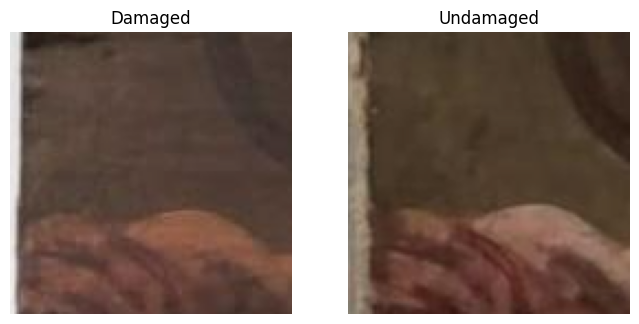

Dataset loaded.
Training patches found: 1427
Test/Eval patches found: 797


In [12]:
# Transforms (Normalize to -1, 1 for GAN)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# ---- DataLoader settings (local-safe defaults) ----
# Mac/VS Code can be finicky with multiprocessing; start with 0, increase later if stable.
NUM_WORKERS = 0

# pin_memory helps only when using CUDA GPU
PIN_MEMORY = (DEVICE == "cuda")

# Create Datasets
if not os.path.isdir(TRAIN_DIR):
    raise FileNotFoundError(f"TRAIN_DIR invalid: {TRAIN_DIR}")

train_dataset = ArtRestorationDataset(TRAIN_DIR, transform=transform)

# TEST_DIR might be None if you only have train
test_dataset = None
if TEST_DIR is not None and os.path.isdir(TEST_DIR):
    test_dataset = ArtRestorationDataset(TEST_DIR, transform=transform)

def find_blank(ds, n_check=2000):
    for k in range(min(len(ds), n_check)):
        dmg, real, dp, rp = ds[k]
        # all-white in normalized space -> everything is +1
        if dmg.min().item() == 1.0 and dmg.max().item() == 1.0:
            return k, dp, rp
    return None

if test_dataset is not None:
    print("Blank tile in test?", find_blank(test_dataset, 3000))
else:
    print("No test_dataset to check.")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,        # recommended for GAN stability
)

print("Training pairs after filtering:", len(train_dataset))

# quick visual + path sanity check
x, y, dmg_p, undmg_p = train_dataset[50]
print("Sample damaged path:", dmg_p)
print("Sample undamaged path:", undmg_p)
print("Damaged min/max:", x.min().item(), x.max().item())
print("Undamaged min/max:", y.min().item(), y.max().item())

show_pair(x, y)   # your earlier visualization helper

test_loader = None
if test_dataset is not None:
    test_loader = DataLoader(
        test_dataset,
        batch_size=4,       # small batch for visualization
        shuffle=False,      # keep deterministic
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

print("Dataset loaded.")
print(f"Training patches found: {len(train_dataset)}")
if test_dataset is not None:
    print(f"Test/Eval patches found: {len(test_dataset)}")
else:
    print("No test/eval dataset found (TEST_DIR is None or invalid).")

In [13]:
xb, yb, dmg_paths, undmg_paths = next(iter(train_loader))
print("Train batch:", xb.shape, yb.shape)
print("Example damaged path:", dmg_paths[0])
print("Example undamaged path:", undmg_paths[0])

Train batch: torch.Size([16, 3, 128, 128]) torch.Size([16, 3, 128, 128])
Example damaged path: /content/tiledsets/train_indexed_images/damaged/042/042_0_4.png
Example undamaged path: /content/tiledsets/train_indexed_images/undamaged/042/042_0_4.png


In [14]:
# ---- Find a textured (non-flat) tile for visualization ----
import torch

def find_textured(ds, n_check=500, var_thresh=0.01):
    for k in range(min(len(ds), n_check)):
        dmg, real, dmg_path, undmg_path = ds[k]
        if max(dmg.var().item(), real.var().item()) > var_thresh:
            return k
    return None

TEXTURED_IDX = find_textured(train_dataset)
print("Textured index:", TEXTURED_IDX)

if TEXTURED_IDX is not None:
    print("Damaged file:", train_dataset.damaged_paths[TEXTURED_IDX])
    print("Undamaged file:", train_dataset.undamaged_paths[TEXTURED_IDX])

Textured index: 0
Damaged file: /content/tiledsets/train_indexed_images/damaged/002/002_0_0.png
Undamaged file: /content/tiledsets/train_indexed_images/undamaged/002/002_0_0.png


#Part 2: The Attention Mechanism

## 4. Self-Attention Block

In [15]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query_conv = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.key_conv   = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_dim, in_dim,      kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W

        # B x N x C'
        query = self.query_conv(x).reshape(B, -1, N).permute(0, 2, 1)
        # B x C' x N
        key   = self.key_conv(x).reshape(B, -1, N)

        # Attention: B x N x N
        energy = torch.bmm(query, key)
        attention = self.softmax(energy)

        # B x C x N
        value = self.value_conv(x).reshape(B, C, N)

        # B x C x N -> B x C x H x W
        out = torch.bmm(value, attention.permute(0, 2, 1)).reshape(B, C, H, W)

        return self.gamma * out + x

In [16]:
sa = SelfAttention(64)
x = torch.randn(2, 64, 32, 32)
y = sa(x)
print(y.shape)

torch.Size([2, 64, 32, 32])


#Part 3: Generator (U-Net Architecture)

## 5. Generator (U-Net with Attention)

In [17]:
class Generator(nn.Module):
    def __init__(self, debug_shapes=False):
        super().__init__()
        self.debug_shapes = debug_shapes

        # Encoder (Downsampling) Input: 3 x 128 x 128
        self.enc1 = self.conv_block(CHANNELS, 64, bn=False)   # 64 x 64 x 64
        self.enc2 = self.conv_block(64, 128)                  # 128 x 32 x 32
        self.enc3 = self.conv_block(128, 256)                 # 256 x 16 x 16
        self.enc4 = self.conv_block(256, 512)                 # 512 x 8 x 8

        # Bottleneck: 512 x 4 x 4
        self.bottleneck = self.conv_block(512, 512)
        self.att_mid = SelfAttention(512)

        # Decoder
        self.up1 = self.up_block(512, 512, dropout=True)      # 512 x 8 x 8
        self.up2 = self.up_block(1024, 256, dropout=False)    # 256 x 16 x 16
        self.att_up2 = SelfAttention(256)

        self.up3 = self.up_block(512, 128)                    # 128 x 32 x 32
        self.up4 = self.up_block(256, 64)                     # 64 x 64 x 64

        self.last = nn.Sequential(
            nn.ConvTranspose2d(128, CHANNELS, kernel_size=4, stride=2, padding=1),  # 3 x 128 x 128
            nn.Tanh()
        )

    def conv_block(self, in_c, out_c, bn=True):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if bn:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def up_block(self, in_c, out_c, dropout=False):
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Bottleneck
        b = self.bottleneck(e4)
        b = self.att_mid(b)

        # Decoder with Skips
        d1 = self.up1(b)
        if self.debug_shapes:
            assert d1.shape[-2:] == e4.shape[-2:], f"d1 {d1.shape} vs e4 {e4.shape}"
        d1 = torch.cat([d1, e4], dim=1)  # 1024 x 8 x 8

        d2 = self.up2(d1)
        d2 = self.att_up2(d2)
        if self.debug_shapes:
            assert d2.shape[-2:] == e3.shape[-2:], f"d2 {d2.shape} vs e3 {e3.shape}"
        d2 = torch.cat([d2, e3], dim=1)  # 512 x 16 x 16

        d3 = self.up3(d2)
        if self.debug_shapes:
            assert d3.shape[-2:] == e2.shape[-2:], f"d3 {d3.shape} vs e2 {e2.shape}"
        d3 = torch.cat([d3, e2], dim=1)  # 256 x 32 x 32

        d4 = self.up4(d3)
        if self.debug_shapes:
            assert d4.shape[-2:] == e1.shape[-2:], f"d4 {d4.shape} vs e1 {e1.shape}"
        d4 = torch.cat([d4, e1], dim=1)  # 128 x 64 x 64

        out = self.last(d4)
        if self.debug_shapes:
            assert out.shape[-2:] == x.shape[-2:], f"out {out.shape} vs x {x.shape}"
        return out

In [18]:
G = Generator(debug_shapes=True).to(DEVICE)
xb, yb, dmg_paths, undmg_paths = next(iter(train_loader))
xb = xb.to(DEVICE)

with torch.no_grad():
    out = G(xb)

print("Input:", xb.shape, xb.min().item(), xb.max().item())
print("Output:", out.shape, out.min().item(), out.max().item())
print("Example damaged path:", dmg_paths[0])
print("Example undamaged path:", undmg_paths[0])

Input: torch.Size([16, 3, 128, 128]) -1.0 1.0
Output: torch.Size([16, 3, 128, 128]) -0.999989926815033 0.9999959468841553
Example damaged path: /content/tiledsets/train_indexed_images/damaged/051/051_4_2.png
Example undamaged path: /content/tiledsets/train_indexed_images/undamaged/051/051_4_2.png


#Part 4: Discriminator (PatchGAN)

## 6. Discriminator (PatchGAN)

In [19]:
class Discriminator(nn.Module):
    def __init__(self, debug_shapes=False):
        super().__init__()
        self.debug_shapes = debug_shapes

        # Input: damaged + (real or fake) => 6 channels
        self.model = nn.Sequential(
            self.d_block(CHANNELS * 2, 64, bn=False),
            self.d_block(64, 128),
            self.d_block(128, 256),
            self.d_block(256, 512),
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)  # Patch map
        )

    def d_block(self, in_c, out_c, bn=True):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if bn:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, img_A, img_B):
        if self.debug_shapes:
            assert img_A.shape == img_B.shape, f"A {img_A.shape} vs B {img_B.shape}"
            assert img_A.shape[1] == CHANNELS, f"Expected {CHANNELS} channels, got {img_A.shape[1]}"

        x = torch.cat([img_A, img_B], dim=1)  # B x 6 x H x W

        if self.debug_shapes:
            assert x.shape[1] == CHANNELS * 2, f"Expected {CHANNELS*2} channels, got {x.shape[1]}"

        return self.model(x)

In [20]:
D = Discriminator(debug_shapes=True).to(DEVICE)

xb, yb, dmg_paths, undmg_paths = next(iter(train_loader))
xb = xb.to(DEVICE)
yb = yb.to(DEVICE)

with torch.no_grad():
    fake = G(xb)
    out_real = D(xb, yb)
    out_fake = D(xb, fake)

print("D(real) shape:", out_real.shape)
print("D(fake) shape:", out_fake.shape)
print("Example damaged path:", dmg_paths[0])
print("Example undamaged path:", undmg_paths[0])

D(real) shape: torch.Size([16, 1, 7, 7])
D(fake) shape: torch.Size([16, 1, 7, 7])
Example damaged path: /content/tiledsets/train_indexed_images/damaged/090/090_1_1.png
Example undamaged path: /content/tiledsets/train_indexed_images/undamaged/090/090_1_1.png


In [21]:
# -------------------------
# 7. Initialization (LINK tested models to training)
# -------------------------
generator = G
discriminator = D

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_pixel = nn.L1Loss()
LAMBDA_PIXEL = 100

optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

print("Training objects ready:",
      "generator", isinstance(generator, nn.Module),
      "discriminator", isinstance(discriminator, nn.Module))

Training objects ready: generator True discriminator True


In [22]:
def make_labels_like(pred, is_real: bool):
    return torch.ones_like(pred) if is_real else torch.zeros_like(pred)

#Part 5: Training Loop

## 7. Initialization

In [23]:
import torch
import matplotlib.pyplot as plt

def show_sample(gen, loader, device, white_thresh=0.92):
    gen.eval()
    with torch.no_grad():
        damaged, real, dmg_paths, real_paths = next(iter(loader))
        damaged = damaged.to(device)
        real = real.to(device)
        fake = gen(damaged)

        # score each tile: want high variance, low fraction of near-white pixels
        best_idx = 0
        best_score = -1e9

        for j in range(damaged.size(0)):
            d = damaged[j]
            r = real[j]

            # compute "white fraction" in UN-normalized space [0,1]
            d01 = (d * 0.5 + 0.5).clamp(0, 1)
            r01 = (r * 0.5 + 0.5).clamp(0, 1)

            d_white = (d01.mean(dim=0) > white_thresh).float().mean().item()
            r_white = (r01.mean(dim=0) > white_thresh).float().mean().item()

            var = max(d.var().item(), r.var().item())
            score = var - 2.0 * max(d_white, r_white)   # penalize white borders hard

            if score > best_score:
                best_score = score
                best_idx = j

        idx = best_idx
        print("Showing idx:", idx, "score:", best_score)
        print("Damaged path:", dmg_paths[idx])
        print("Undamaged path:", real_paths[idx])

        def to_img(t):
            t = t[idx].detach().cpu().float()
            t = (t * 0.5 + 0.5).clamp(0, 1)
            return t.permute(1, 2, 0).numpy()

        fig, axes = plt.subplots(1, 3, figsize=(10, 4))
        axes[0].imshow(to_img(damaged)); axes[0].set_title("Damaged Input"); axes[0].axis("off")
        axes[1].imshow(to_img(fake));    axes[1].set_title("Restored (Generated)"); axes[1].axis("off")
        axes[2].imshow(to_img(real));    axes[2].set_title("Ground Truth"); axes[2].axis("off")
        plt.tight_layout()
        plt.show()

    gen.train()

## 8. Training Loop

In [25]:
EPOCHS = 3
VIS_EVERY = 5

print("Starting Training...")

for epoch in range(EPOCHS):
    for i, (damaged_imgs, real_imgs, dmg_paths, undmg_paths) in enumerate(train_loader):
        damaged_imgs = damaged_imgs.to(DEVICE)
        real_imgs = real_imgs.to(DEVICE)

        # ------------------
        # Train Discriminator
        # ------------------
        optimizer_D.zero_grad()

        with torch.no_grad():
            gen_imgs = generator(damaged_imgs)

        pred_real = discriminator(damaged_imgs, real_imgs)
        pred_fake = discriminator(damaged_imgs, gen_imgs)

        valid = torch.ones_like(pred_real, device=DEVICE)
        fake = torch.zeros_like(pred_fake, device=DEVICE)

        loss_D_real = criterion_GAN(pred_real, valid)
        loss_D_fake = criterion_GAN(pred_fake, fake)
        loss_D = 0.5 * (loss_D_real + loss_D_fake)

        loss_D.backward()
        optimizer_D.step()

        # ------------------
        # Train Generator
        # ------------------
        optimizer_G.zero_grad()

        gen_imgs = generator(damaged_imgs)
        pred_fake_for_G = discriminator(damaged_imgs, gen_imgs)

        valid_for_G = torch.ones_like(pred_fake_for_G, device=DEVICE)

        loss_GAN = criterion_GAN(pred_fake_for_G, valid_for_G)
        loss_pixel = criterion_pixel(gen_imgs, real_imgs)
        loss_G = loss_GAN + (LAMBDA_PIXEL * loss_pixel)

        loss_G.backward()
        optimizer_G.step()

        if i % 50 == 0:
            print(
                f"epoch {epoch+1}/{EPOCHS}  iter {i}/{len(train_loader)}  "
                f"D {loss_D.item():.3f}  G {loss_G.item():.3f}  "
                f"(GAN {loss_GAN.item():.3f}, L1 {loss_pixel.item():.3f})"
            )

    # visualize every VIS_EVERY epochs
    if (epoch + 1) % VIS_EVERY == 0:
        print(f"\n--- VIS epoch {epoch+1} ---")
        if test_loader is not None:
            show_sample(generator, test_loader if test_loader is not None else train_loader, DEVICE)
        else:
            show_sample(generator, test_loader if test_loader is not None else train_loader, DEVICE)

Starting Training...
epoch 1/3  iter 0/89  D 0.239  G 32.672  (GAN 2.142, L1 0.305)
epoch 1/3  iter 50/89  D 0.089  G 25.850  (GAN 2.948, L1 0.229)
epoch 2/3  iter 0/89  D 0.266  G 26.258  (GAN 2.907, L1 0.234)
epoch 2/3  iter 50/89  D 1.196  G 29.360  (GAN 1.022, L1 0.283)
epoch 3/3  iter 0/89  D 0.329  G 27.163  (GAN 1.556, L1 0.256)
epoch 3/3  iter 50/89  D 0.077  G 26.695  (GAN 3.475, L1 0.232)


In [28]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np
import torch

def benchmark_gan_quantitative_robust(gen_model, loader, device):
    """
    Evaluates the Generator model on the test set using PSNR and SSIM metrics.
    Robust to dataloaders returning extra information (like filenames).
    """
    gen_model.eval()
    psnr_scores = []
    ssim_scores = []

    print(f"🚀 Starting benchmark on {len(loader.dataset)} test images...")

    with torch.no_grad():
        # ROBUST FIX: Retrieve the whole batch tuple instead of unpacking strictly
        for batch in loader:
            # Extract only the first 2 elements (Input, Target) and ignore the rest (e.g., filenames)
            inputs = batch[0]
            targets = batch[1]

            inputs = inputs.to(device)
            targets = targets.to(device)

            # 1. Generate Fake Images
            fake_imgs = gen_model(inputs)

            # 2. Denormalize: Convert from [-1, 1] range back to [0, 1]
            fake_imgs = (fake_imgs * 0.5 + 0.5).clamp(0, 1).cpu().numpy()
            targets_np = (targets * 0.5 + 0.5).cpu().numpy()

            # 3. Calculate metrics for each image in the batch
            batch_size = fake_imgs.shape[0]
            for i in range(batch_size):
                # Permute dimensions: PyTorch (C, H, W) -> Skimage (H, W, C)
                img_pred = np.moveaxis(fake_imgs[i], 0, -1)
                img_true = np.moveaxis(targets_np[i], 0, -1)

                # Calculate PSNR and SSIM
                p = psnr(img_true, img_pred, data_range=1.0)
                s = ssim(img_true, img_pred, data_range=1.0, channel_axis=2)

                psnr_scores.append(p)
                ssim_scores.append(s)

    # 4. Display Results
    print("\n" + "="*30)
    print(f" QUANTITATIVE RESULTS (SMA-GAN)")
    print("="*30)
    print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB (Higher is better)")
    print(f"Average SSIM: {np.mean(ssim_scores):.4f}    (Closer to 1.0 is better)")
    print("="*30)

# Run the benchmark
benchmark_gan_quantitative_robust(generator, test_loader, DEVICE)

🚀 Starting benchmark on 797 test images...

 QUANTITATIVE RESULTS (SMA-GAN)
Average PSNR: 16.50 dB (Higher is better)
Average SSIM: 0.4178    (Closer to 1.0 is better)
